In [123]:
# Import libraries
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os

## Lectura de los archivos

In [41]:
# Get files path
from pathlib import Path

folder_path = Path('images')

# Filter the directory contents to include files only
files = [f.name for f in folder_path.iterdir()]

files_corr = files[:-1]

In [42]:
# Check files path
files_corr

['envisat_wsm_2007_03_26_hh_pot_cal_cg_gk5wgs84_nn_sub.tif',
 'envisat_wsm_2008_05_19_hh_pot_cal_cg_gk5wgs84_nn_sub.tif',
 'envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub.tif']

In [132]:
# Read vector samples
gdf_samples = gpd.read_file('Muestras/muestras_TP5_todas.shp')#.to_crs(epsg=9001)

# --
gdf_samples['Cobertura'] = gdf_samples['nombre'].str[:-1]

# Display vector samples
gdf_samples.sample(5)

,Id,nombre,geometry,Cobertura
9,10,pastizal1,"POLYGON ((5575671.617 6306784.165, 5574349.786...",pastizal
11,20,pajonal1,"POLYGON ((5628589.182 6236890.653, 5629843.558...",pajonal
6,9,bosque2,"POLYGON ((5612962.947 6218217.385, 5613598.154...",bosque
2,2,juncal2,"POLYGON ((5578458.476 6242199.887, 5578899.413...",juncal
3,1,juncal1,"POLYGON ((5562713.321 6276088.641, 5563323.466...",juncal


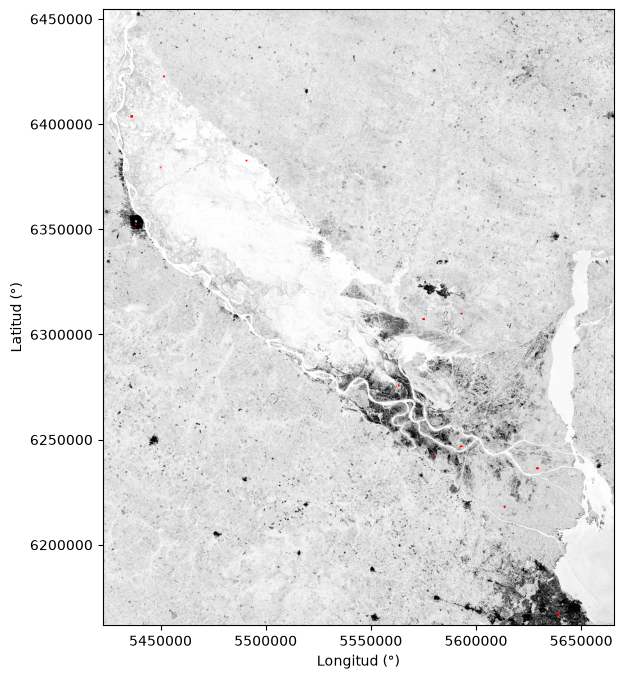

In [43]:
# Visualizo junto a los polígonos de muestreo

# Abro una de las imágenes
with rio.open(os.path.join('images', files_corr[0])) as src:
    img = src.read()
    extent = plotting_extent(src) 

# Reproyecto el archivo vectorial
gdf_samples = gdf_samples.to_crs(src.crs)

# Ploteamos la imagen con los vectores superpuestos
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img[0], extent = extent, 
          cmap ='Grays',
          vmin=np.nanpercentile(img[0], 1), vmax=np.nanpercentile(img[0], 99))
gdf_samples.plot(ax=ax, legend = True, color='red')
ax.ticklabel_format(style='plain')

# Etiquetas y título
ax.set_ylabel('Latitud (°)')
ax.set_xlabel('Longitud (°)')

plt.show()

## Extracción de los datos de backscatering a un diccionario

**Estructura:**
1) Fecha
2) Tipo de cobertura
3) Estadísticos: Mediana, desvío estándar, primer quantil, y tercer quantil (En dB)

In [78]:
# --
samp_unique = gdf_samples['Cobertura'].unique()

# --
samp_unique

<StringArray>
['laguna', 'juncal', 'ciudad', 'bosque', 'pastizal', 'pajonal', 'pradera']
Length: 7, dtype: str

In [ ]:
# --
dict_samp_seas = {}

# --
for p in files_corr:
#p = files_corr[0]

    with rio.open(os.path.join('images', p)) as src:
        #print('-'.join(p.split('_')[2:4]))
        dict_samp = {}
        # --

        # --

        for s in samp_unique:
            #print(s)
            sample_sel = gdf_samples[gdf_samples['Cobertura']==s]
            mask_data, mask_transform = mask(dataset=src, shapes=sample_sel.geometry, nodata=None, crop=True)
            # --
            x = mask_data
            x[0][x[0] == 0] = np.nan 
            x = x[~np.isnan(x)] # Remove nan values
            # --
            #print(x.flatten())
            dict_vals = {}
            dict_vals['values'] = x.flatten()
            dict_vals['median_dec'] = 10*np.log10(np.median(x))
            dict_vals['std_dec'] = 10*np.log10(np.std(x))
            dict_vals['25q_dec'] = 10*np.log10(np.quantile(x, 0.25))
            dict_vals['75q_dec'] = 10*np.log10(np.quantile(x, 0.75))
            
            # --
            dict_samp[s] = dict_vals
            
        # --
        dict_samp_seas[f'{'-'.join(p.split('_')[2:4])}'] = dict_samp
            


## Visualización de los resultados

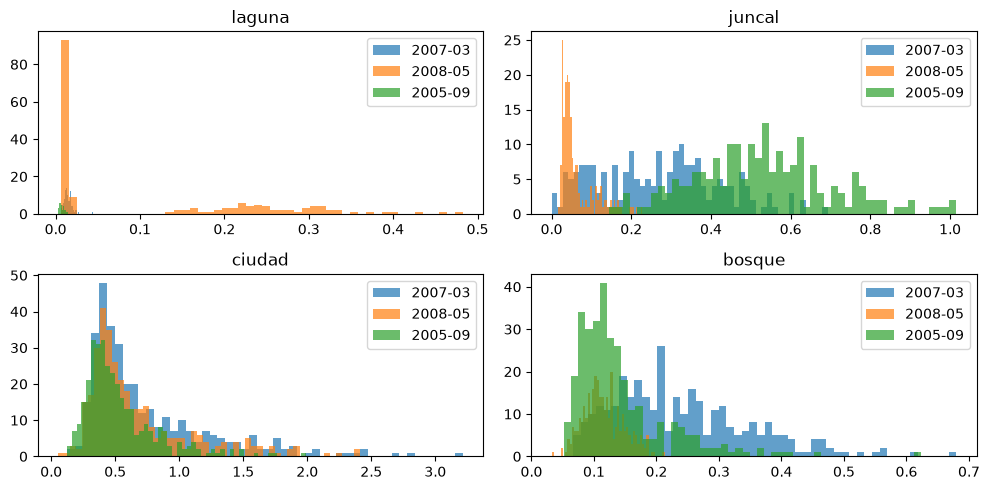

In [104]:
# --
fig, ax = plt.subplots(2, 2, figsize=(10, 5), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[:4]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        ax[idx].hist(values , bins=50, alpha=0.7, label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

In [118]:
list(dict_samp_seas['2005-09']['laguna'].keys())[1:]

['median_dec', 'std_dec', '25q_dec', '75q_dec']

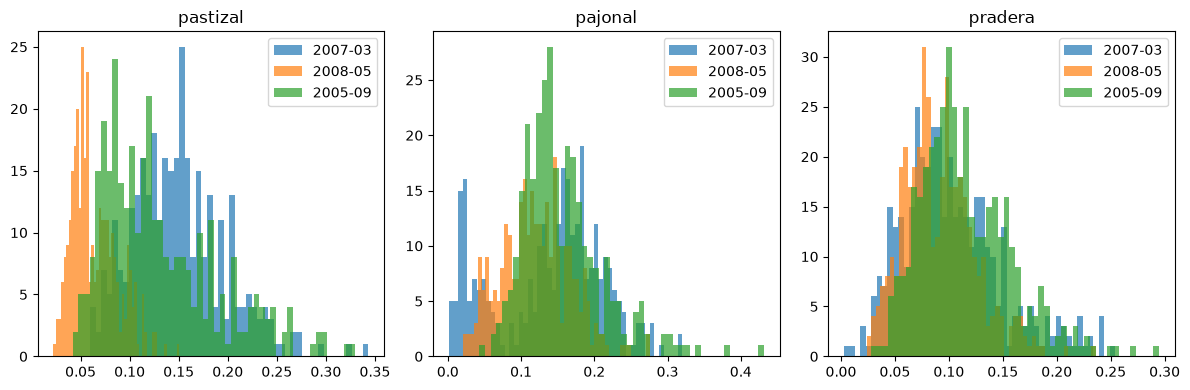

In [108]:
# --
fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[4:]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        ax[idx].hist(values , bins=50, alpha=0.7, label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

## Desempaquetado de las estadísticos y exportación de los resultados

In [ ]:
# Desempaquetado de los datos
def desmp_dict(dict, d, list_res):
    
    # --
    dict_eval = dict[d]
    
    # --
    for s in dict_eval.keys():
        list_res.append([d, s, 
                         dict_eval[s]['median_dec'],
                         dict_eval[s]['std_dec'],
                         dict_eval[s]['25q_dec'],
                         dict_eval[s]['75q_dec']])

In [120]:
# --
list_res = []

# --
for d in dict_samp_seas.keys():
    desmp_dict(dict_samp_seas, d, list_res)

In [127]:
# --
df_results = pd.DataFrame(list_res, columns = ['Fecha', 'Cobertura', 'Mediana', 'StD', '25q', '75q'])

In [128]:
# --
df_results.sample(10)

,Fecha,Cobertura,Mediana,StD,25q,75q
17,2005-09,bosque,-9.238754,-11.290965,-10.286036,-8.018180
8,2008-05,juncal,-13.465901,-13.535732,-14.569201,-11.558174
16,2005-09,ciudad,-3.496307,-5.374110,-4.606335,-1.969815
9,2008-05,ciudad,-2.815750,-3.801459,-3.963115,-1.119440
0,2007-03,laguna,-18.644621,-23.375280,-19.453058,-17.719519
13,2008-05,pradera,-10.695097,-14.792319,-11.723701,-9.567185
19,2005-09,pajonal,-8.425740,-12.575527,-9.246458,-7.432695
1,2007-03,juncal,-5.607794,-8.140951,-8.629715,-4.352558
20,2005-09,pradera,-9.682313,-13.784960,-10.652994,-8.486473
14,2005-09,laguna,-22.079487,-25.607565,-23.022310,-20.442417


In [131]:
# --
df_results.to_excel("results.xlsx", index=False)